# Polymarket vs. ESPN & Sportsbooks
**NFL 2025 Season — Notebook 4**

> **Context:** Notebooks 1 and 2 scored ESPN and the 7-book sportsbook consensus as probability models. This notebook adds a fourth model: **Polymarket**, a decentralised prediction market where anyone can bet real money on game outcomes with no vig. Because Polymarket is crowd-sourced and vig-free, it represents a structurally different information aggregation mechanism — one closer to a pure market than a bookmaker's pricing model.
>
> **Key distinction:** Polymarket `opening_price` is the first available probability after the market was created (days or weeks before kickoff). This is the correct pre-game forecast to use for calibration. The `closing_price` field in the CSV is the resolved settlement price (0 or 1) — not a pre-game prediction.

---

## Notebook Roadmap

| # | Section | What | Why |
|---|---------|------|-----|
| 1 | **Setup** | Load and merge data, define helpers | Join Polymarket opening prices to the main game dataset |
| 2 | **4-Model Brier Score Comparison** | Add Polymarket to the ESPN vs. consensus calibration table from Notebook 2 | Where does a vig-free crowd market rank vs. bookmakers and ESPN? |
| 3 | **Polymarket vs. ESPN Divergence** | Games where Polymarket and ESPN disagree most — who was right? | Tests whether the crowd or the broadcaster had better signal |
| 4 | **Price Movement: Open to Close** | How much did Polymarket probabilities move from market open to final pre-game price | Movement signals new information entering the market — analogous to sportsbook line movement |
| 5 | **Volume Analysis** | Total trading volume, distribution by game, breakdown by market type | Higher-volume games attract sharper attention — does it improve calibration? |
| 6 | **Super Bowl Deep Dive** | Full 14-day price trajectory for Seahawks vs. Patriots using the 6H history data | The highest-volume game in the dataset as a case study in market consensus formation |
| 7 | **Export** | Save outputs | Handoff for Notebooks 6 and 7 |

---

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.utils import load_data, BOOKS, ml_to_implied_prob
from src.calibration import brier_score, brier_skill_score

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)

NAIVE_BS = 0.25  # baseline for BSS calculation

# ── Load ────────────────────────────────────────────────────────────────────
df      = load_data('../data/nfl2025_complete.xlsx')
closing = pd.read_csv('../outputs/polymarket_closing_prices.csv')
h6      = pd.read_csv('../outputs/polymarket_all_6h.csv')

# Standardise date types
df['date']      = df['date'].astype(str)
closing['date'] = closing['date'].astype(str)
h6['date']      = h6['date'].astype(str)
h6['datetime']  = pd.to_datetime(h6['datetime'])

# Merge Polymarket into main dataset
merged = df.merge(closing, on=['away_team','home_team','date'], how='left', suffixes=('','_pm'))
merged['away_win'] = (merged['winner'] == merged['away_team']).astype(int)

# ESPN implied probability (raw, includes vig)
merged['espn_away_prob'] = merged['espn_away_ml'].apply(
    lambda x: 100/(x+100) if pd.notna(x) and x > 0 else (abs(x)/(abs(x)+100) if pd.notna(x) else np.nan))

# Consensus implied probability (mean of 7 books, raw)
for b in BOOKS:
    merged[f'_pa_{b}'] = merged[f'{b}_away_ml'].apply(ml_to_implied_prob)
merged['consensus_away'] = merged[[f'_pa_{b}' for b in BOOKS]].mean(axis=1)

print(f'Games: {len(merged)}')
print(f'Polymarket coverage: {merged["polymarket_away_open"].notna().sum()} / {len(merged)}')
merged[['away_team','home_team','date','polymarket_away_open','polymarket_away_close',
        'volume_total']].head(4)

Games: 285
Polymarket coverage: 283 / 285


,away_team,home_team,date,polymarket_away_open,polymarket_away_close,volume_total
0,Dallas Cowboys,Philadelphia Eagles,2025-09-04,0.2400,0.0000,4374523.3342
1,Kansas City Chiefs,Los Angeles Chargers,2025-09-05,0.6050,0.0000,3268723.1466
2,Carolina Panthers,Jacksonville Jaguars,2025-09-07,0.3950,0.0000,374925.5468
3,Pittsburgh Steelers,New York Jets,2025-09-07,0.5800,1.0000,1091264.0704


## 2. Four-Model Brier Score Comparison

**What:** Add Polymarket's opening probability to the Brier Score leaderboard from Notebook 2. Compare ESPN, the 7-book consensus, and Polymarket on the same 285-game sample.

**Why the opening price:** Polymarket's closing price is the settlement value (0 or 1 after the game resolves) — not a forecast. The opening price is the market's first pre-game probability, analogous to a bookmaker's opening line.

**Brier Score recap:** Lower is better. 0.25 is the naive baseline (always predict 50/50). The Brier Skill Score (BSS) measures improvement over that baseline — higher is better.

**Figure meaning:** The bar chart ranks all four models by BSS. A model beating the sportsbook consensus would be a significant finding — the consensus represents the aggregated view of professional bookmakers.

In [2]:
pm_sub = merged[merged['polymarket_away_open'].notna()]

models = {
    'Naive (50/50)':      (pd.Series([0.5]*len(pm_sub)), pm_sub['away_win']),
    'ESPN':               (pm_sub['espn_away_prob'].dropna(),
                           pm_sub.loc[pm_sub['espn_away_prob'].notna(),'away_win']),
    'Polymarket':         (pm_sub['polymarket_away_open'], pm_sub['away_win']),
    'Sportsbook Consensus': (pm_sub['consensus_away'].dropna(),
                              pm_sub.loc[pm_sub['consensus_away'].notna(),'away_win']),
}

results = []
for name, (preds, actuals) in models.items():
    bs  = brier_score(preds, actuals)
    bss = 1 - bs / NAIVE_BS
    results.append({'Model': name, 'Brier Score': bs, 'BSS': bss, 'n': len(actuals)})

brier_df = pd.DataFrame(results).sort_values('Brier Score')
print('4-Model Brier Score Comparison:')
brier_df.set_index('Model')[['Brier Score','BSS','n']].round(4)

4-Model Brier Score Comparison:


,Brier Score,BSS,n
Model,,,
Sportsbook Consensus,0.2103,0.1588,283
ESPN,0.2216,0.1134,283
Polymarket,0.2224,0.1103,283
Naive (50/50),0.2500,0.0000,283


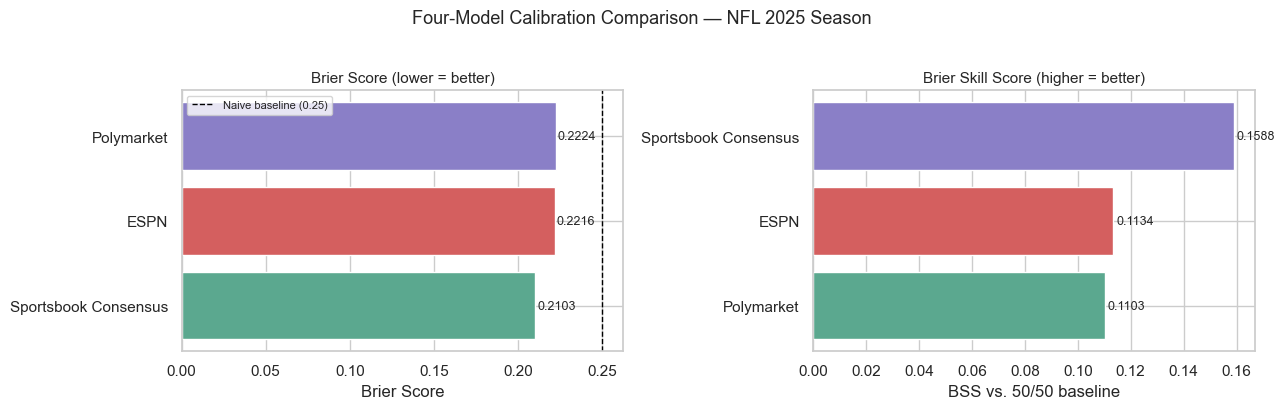

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_df = brier_df[brier_df['Model'] != 'Naive (50/50)'].sort_values('Brier Score')
colors_bs  = ['#5ba88f' if m == 'Sportsbook Consensus' else
              '#d45f5f' if m == 'ESPN' else '#8a7fc7'
              for m in plot_df['Model']]
colors_bss = ['#5ba88f' if m == 'Sportsbook Consensus' else
              '#d45f5f' if m == 'ESPN' else '#8a7fc7'
              for m in plot_df.sort_values('BSS', ascending=False)['Model']]

# Brier Score (lower = better)
axes[0].barh(plot_df['Model'], plot_df['Brier Score'], color=colors_bs, edgecolor='white')
axes[0].axvline(NAIVE_BS, color='black', linestyle='--', linewidth=1, label='Naive baseline (0.25)')
axes[0].set_title('Brier Score (lower = better)', fontsize=11)
axes[0].set_xlabel('Brier Score')
axes[0].legend(fontsize=8)
for bar, val in zip(axes[0].patches, plot_df['Brier Score']):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# BSS (higher = better)
bss_sorted = plot_df.sort_values('BSS', ascending=True)
axes[1].barh(bss_sorted['Model'], bss_sorted['BSS'], color=colors_bss, edgecolor='white')
axes[1].set_title('Brier Skill Score (higher = better)', fontsize=11)
axes[1].set_xlabel('BSS vs. 50/50 baseline')
for bar, val in zip(axes[1].patches, bss_sorted['BSS']):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Four-Model Calibration Comparison — NFL 2025 Season', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Polymarket vs. ESPN Divergence

**What:** Identify games where Polymarket's opening probability and ESPN's pre-game win probability diverge by more than 5 percentage points. Measure which model was right when they disagreed.

**Why this matters:** Divergence between a crowd-sourced market and a broadcaster's model reveals which type of signal is better informed. If Polymarket's favoured team wins more often when the two disagree, it means the crowd had better information than ESPN's model.

**Figure meaning:** The scatter shows all 285 games with ESPN probability on the x-axis and Polymarket opening probability on the y-axis. Games above the diagonal had Polymarket more bullish on the away team; games below had ESPN more bullish. Colour indicates who won.

In [4]:
merged['pm_espn_diff'] = merged['polymarket_away_open'] - merged['espn_away_prob']

pm_higher   = merged[merged['pm_espn_diff'] >  0.05]
espn_higher = merged[merged['pm_espn_diff'] < -0.05]
close       = merged[merged['pm_espn_diff'].abs() <= 0.05]

print('=== POLYMARKET vs ESPN DIVERGENCE ===')
print(f'Total games                         : {merged["pm_espn_diff"].notna().sum()}')
print(f'Mean abs divergence                 : {merged["pm_espn_diff"].abs().mean():.4f} ({merged["pm_espn_diff"].abs().mean()*100:.1f}pp)')
print()
print(f'PM > ESPN away by >5pp              : {len(pm_higher)} games')
print(f'  → Away team win rate              : {pm_higher["away_win"].mean():.3f} ({pm_higher["away_win"].mean()*100:.1f}%)')
print()
print(f'ESPN > PM away by >5pp              : {len(espn_higher)} games')
print(f'  → Away team win rate              : {espn_higher["away_win"].mean():.3f} ({espn_higher["away_win"].mean()*100:.1f}%)')
print()
print(f'Within 5pp (models agree)           : {len(close)} games')
print(f'  → Away team win rate              : {close["away_win"].mean():.3f} ({close["away_win"].mean()*100:.1f}%)')
print()
print('Top 10 games where PM was most bullish on away vs ESPN:')
top_pm = merged.nlargest(10,'pm_espn_diff')[['week','away_team','home_team',
                                              'polymarket_away_open','espn_away_prob',
                                              'pm_espn_diff','away_win']]
top_pm.reset_index(drop=True)

=== POLYMARKET vs ESPN DIVERGENCE ===
Total games                         : 283
Mean abs divergence                 : 0.1022 (10.2pp)

PM > ESPN away by >5pp              : 62 games
  → Away team win rate              : 0.387 (38.7%)

ESPN > PM away by >5pp              : 89 games
  → Away team win rate              : 0.562 (56.2%)

Within 5pp (models agree)           : 132 games
  → Away team win rate              : 0.447 (44.7%)

Top 10 games where PM was most bullish on away vs ESPN:


,week,away_team,home_team,polymarket_away_open,espn_away_prob,pm_espn_diff,away_win
0,2,Buffalo Bills,New York Jets,0.7750,0.2778,0.4972,1
1,2,San Francisco 49ers,New Orleans Saints,0.7550,0.2778,0.4772,1
2,8,Tennessee Titans,Indianapolis Colts,0.5450,0.1000,0.4450,0
3,11,New York Jets,New England Patriots,0.5450,0.1250,0.4200,0
4,9,New Orleans Saints,Los Angeles Rams,0.5250,0.1111,0.4139,0
5,9,Carolina Panthers,Green Bay Packers,0.5300,0.1250,0.4050,1
6,12,New York Jets,Baltimore Ravens,0.5050,0.1000,0.4050,0
7,15,Indianapolis Colts,Seattle Seahawks,0.5200,0.1290,0.3910,0
8,9,Minnesota Vikings,Detroit Lions,0.5650,0.2083,0.3567,1
9,18,Green Bay Packers,Minnesota Vikings,0.6000,0.2500,0.3500,0


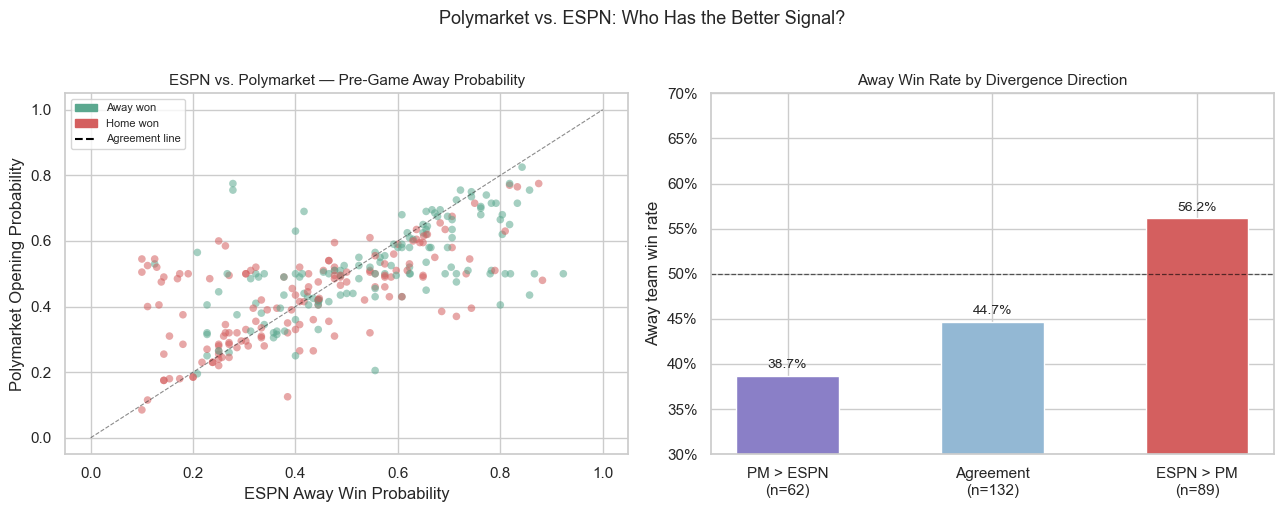

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: ESPN vs Polymarket probability
sub = merged[merged['pm_espn_diff'].notna() & merged['espn_away_prob'].notna()]
colors = ['#5ba88f' if w == 1 else '#d45f5f' for w in sub['away_win']]
axes[0].scatter(sub['espn_away_prob'], sub['polymarket_away_open'],
                c=colors, alpha=0.55, s=30, edgecolors='none')
axes[0].plot([0,1],[0,1], 'k--', linewidth=0.8, alpha=0.5, label='Perfect agreement')
axes[0].set_xlabel('ESPN Away Win Probability')
axes[0].set_ylabel('Polymarket Opening Probability')
axes[0].set_title('ESPN vs. Polymarket — Pre-Game Away Probability', fontsize=11)
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#5ba88f', label='Away won'),
    Patch(color='#d45f5f', label='Home won'),
    plt.Line2D([0],[0],color='black',linestyle='--',label='Agreement line')
], fontsize=8)

# Bar: Win rate when each model was more confident
groups = ['PM > ESPN\n(n={})'.format(len(pm_higher)),
          'Agreement\n(n={})'.format(len(close)),
          'ESPN > PM\n(n={})'.format(len(espn_higher))]
win_rates = [pm_higher['away_win'].mean(),
             close['away_win'].mean(),
             espn_higher['away_win'].mean()]
bar_colors = ['#8a7fc7','#93b8d4','#d45f5f']
bars = axes[1].bar(groups, win_rates, color=bar_colors, edgecolor='white', width=0.5)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=0.9, alpha=0.6)
axes[1].set_title('Away Win Rate by Divergence Direction', fontsize=11)
axes[1].set_ylabel('Away team win rate')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1].set_ylim(0.3, 0.7)
for bar, val in zip(bars, win_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.008,
                 f'{val:.1%}', ha='center', fontsize=10)

plt.suptitle('Polymarket vs. ESPN: Who Has the Better Signal?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Price Movement: Open to Final Pre-Game

**What:** Extract the final pre-game probability from the 6H history data and compare it to the opening probability. Measure how much Polymarket prices moved between market creation and kickoff.

**Why it matters:** Polymarket price movement is the prediction market equivalent of a sportsbook line move. Large movements signal new information — injuries, weather, roster changes, or sharp crowd money. Games where Polymarket moved significantly are candidates for Notebook 6's sharp money analysis.

**Figure meaning:** The histogram shows the distribution of probability shifts from open to close. Games with extreme movements (>15pp) are annotated. The scatter shows whether large movements predicted outcomes — if markets moved in the right direction, it validates the wisdom-of-crowds effect.

In [6]:
# Get final pre-kickoff price from 6H histories
h6_away = h6[h6['side'] == 'away'].copy()
h6_away['game_date'] = pd.to_datetime(h6_away['date'])
h6_pre  = h6_away[h6_away['datetime'] < h6_away['game_date']]
h6_last = (h6_pre.sort_values('timestamp')
                 .groupby(['away_team','home_team','date'])
                 .last()
                 .reset_index()
                 .rename(columns={'probability': 'pm_final_pre'}))

merged = merged.merge(h6_last[['away_team','home_team','date','pm_final_pre']],
                      on=['away_team','home_team','date'], how='left')
merged['pm_movement'] = merged['pm_final_pre'] - merged['polymarket_away_open']

print('=== POLYMARKET PRICE MOVEMENT (open → final pre-game) ===')
print(f'Games with data     : {merged["pm_movement"].notna().sum()}')
print(f'Mean movement       : {merged["pm_movement"].mean():.4f}')
print(f'Std dev             : {merged["pm_movement"].std():.4f}')
print(f'Moved toward away (+>2pp) : {(merged["pm_movement"] > 0.02).sum()} games')
print(f'Moved toward home (-<2pp) : {(merged["pm_movement"] < -0.02).sum()} games')
print(f'Stable (±2pp)             : {(merged["pm_movement"].abs() <= 0.02).sum()} games')
print()
print('Top 10 largest Polymarket movements:')
top_pm_move = (
    merged.assign(abs_move=merged['pm_movement'].abs())
          .nlargest(10,'abs_move')
          [['week','away_team','home_team','polymarket_away_open',
            'pm_final_pre','pm_movement','away_win']]
          .reset_index(drop=True)
)
top_pm_move

=== POLYMARKET PRICE MOVEMENT (open → final pre-game) ===
Games with data     : 283
Mean movement       : -0.0046
Std dev             : 0.1178
Moved toward away (+>2pp) : 100 games
Moved toward home (-<2pp) : 111 games
Stable (±2pp)             : 72 games

Top 10 largest Polymarket movements:


,week,away_team,home_team,polymarket_away_open,pm_final_pre,pm_movement,away_win
0,8,Tennessee Titans,Indianapolis Colts,0.5450,0.0950,-0.4500,0
1,9,New Orleans Saints,Los Angeles Rams,0.5250,0.1050,-0.4200,0
2,9,Carolina Panthers,Green Bay Packers,0.5300,0.1150,-0.4150,1
3,17,Denver Broncos,Kansas City Chiefs,0.4750,0.8850,0.4100,1
4,11,New York Jets,New England Patriots,0.5450,0.1450,-0.4000,0
5,18,Green Bay Packers,Minnesota Vikings,0.6000,0.2050,-0.3950,0
6,9,Los Angeles Chargers,Tennessee Titans,0.4350,0.8250,0.3900,1
7,9,Minnesota Vikings,Detroit Lions,0.5650,0.1900,-0.3750,1
8,8,Buffalo Bills,Carolina Panthers,0.4050,0.7750,0.3700,1
9,8,New York Giants,Philadelphia Eagles,0.5850,0.2450,-0.3400,0


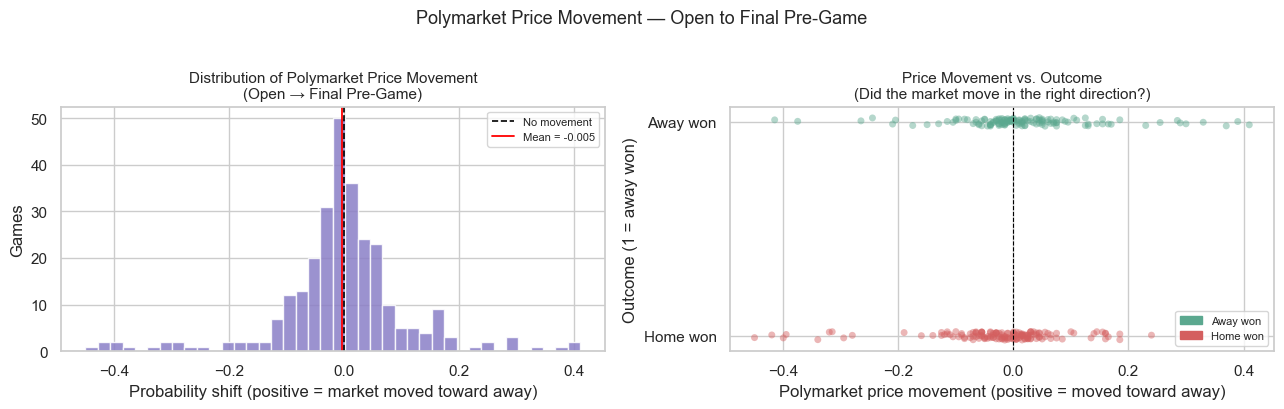

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of movements
axes[0].hist(merged['pm_movement'].dropna(), bins=40, color='#8a7fc7', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.2, label='No movement')
axes[0].axvline(merged['pm_movement'].mean(), color='red', linewidth=1.3,
                label=f'Mean = {merged["pm_movement"].mean():.3f}')
axes[0].set_title('Distribution of Polymarket Price Movement\n(Open → Final Pre-Game)', fontsize=11)
axes[0].set_xlabel('Probability shift (positive = market moved toward away)')
axes[0].set_ylabel('Games')
axes[0].legend(fontsize=8)

# Scatter: movement vs outcome
sub = merged[merged['pm_movement'].notna()]
colors = ['#5ba88f' if w == 1 else '#d45f5f' for w in sub['away_win']]
axes[1].scatter(sub['pm_movement'], sub['away_win'] + np.random.uniform(-0.02, 0.02, len(sub)),
                c=colors, alpha=0.45, s=25, edgecolors='none')
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Polymarket price movement (positive = moved toward away)')
axes[1].set_ylabel('Outcome (1 = away won)')
axes[1].set_title('Price Movement vs. Outcome\n(Did the market move in the right direction?)', fontsize=11)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Home won', 'Away won'])
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#5ba88f', label='Away won'),
    Patch(color='#d45f5f', label='Home won'),
], fontsize=8)

plt.suptitle('Polymarket Price Movement — Open to Final Pre-Game', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Volume Analysis

**What:** Analyse trading volume across all 285 games — total season volume, distribution by game importance, breakdown by market type (moneyline, spread, totals), and whether higher-volume games produce better-calibrated prices.

**Why volume matters:** A prediction market with thin liquidity can have noisy prices — a small number of bettors can move the price significantly without much information. High-volume games attract more bettors, which should pull prices closer to the true probability.

**Figure meaning:**
- Left: Distribution of per-game volume — a heavily right-skewed distribution showing most games are low-volume with a few extreme outliers (playoffs)
- Right: Brier Score by volume quartile — tests whether the wisdom-of-crowds effect improves with more participants

In [8]:
print('=== SEASON VOLUME SUMMARY ===')
print(f'Total season volume   : ${merged["volume_total"].sum():,.0f}')
print(f'Mean per game         : ${merged["volume_total"].mean():,.0f}')
print(f'Median per game       : ${merged["volume_total"].median():,.0f}')
print(f'Max (Super Bowl)      : ${merged["volume_total"].max():,.0f}')
print()
print('Volume by market type (full season):')
print(f'  Moneyline : ${merged["volume_moneyline"].sum():,.0f} ({merged["volume_moneyline"].sum()/merged["volume_total"].sum():.1%})')
print(f'  Spread    : ${merged["volume_spread"].sum():,.0f} ({merged["volume_spread"].sum()/merged["volume_total"].sum():.1%})')
print(f'  Totals    : ${merged["volume_totals"].sum():,.0f} ({merged["volume_totals"].sum()/merged["volume_total"].sum():.1%})')
print()
print('Top 10 highest-volume games:')
top_vol = (
    merged.nlargest(10,'volume_total')
          [['week','away_team','home_team','volume_total','polymarket_away_open','away_win']]
          .copy()
)
top_vol['volume_total'] = top_vol['volume_total'].apply(lambda x: f'${x:,.0f}')
top_vol.reset_index(drop=True)

=== SEASON VOLUME SUMMARY ===
Total season volume   : $1,138,739,507
Mean per game         : $3,995,577
Median per game       : $2,752,358
Max (Super Bowl)      : $55,291,755

Volume by market type (full season):
  Moneyline : $853,131,403 (74.9%)
  Spread    : $207,811,536 (18.2%)
  Totals    : $57,933,093 (5.1%)

Top 10 highest-volume games:


,week,away_team,home_team,volume_total,polymarket_away_open,away_win
0,SB,Seattle Seahawks,New England Patriots,"$55,291,755",0.6750,1
1,CC,New England Patriots,Denver Broncos,"$18,709,802",0.6850,1
2,CC,Los Angeles Rams,Seattle Seahawks,"$18,294,806",0.4250,0
3,DIV,Houston Texans,New England Patriots,"$17,214,222",0.3850,0
4,DIV,Los Angeles Rams,Chicago Bears,"$16,364,538",0.6450,1
5,14,Dallas Cowboys,Detroit Lions,"$15,230,510",0.2650,0
6,WC,Buffalo Bills,Jacksonville Jaguars,"$14,075,157",0.5250,1
7,DIV,Buffalo Bills,Denver Broncos,"$13,866,742",0.4950,0
8,DIV,San Francisco 49ers,Seattle Seahawks,"$13,082,196",0.2450,0
9,WC,San Francisco 49ers,Philadelphia Eagles,"$12,483,414",0.3250,1


In [9]:
# Volume vs calibration
vol_q = pd.qcut(merged['volume_total'], 4, labels=['Q1 (low)','Q2','Q3','Q4 (high)'])
vol_cal = []
for q in ['Q1 (low)','Q2','Q3','Q4 (high)']:
    sub = merged[vol_q == q]
    sub_clean = sub[sub['polymarket_away_open'].notna()]
    bs  = brier_score(sub_clean['polymarket_away_open'], sub_clean['away_win'])
    bss = 1 - bs / NAIVE_BS
    vol_cal.append({
        'Volume Quartile': q,
        'n': len(sub_clean),
        'Median Volume': sub['volume_total'].median(),
        'Brier Score': bs,
        'BSS': bss,
    })

vol_cal_df = pd.DataFrame(vol_cal)
vol_cal_df['Median Volume'] = vol_cal_df['Median Volume'].apply(lambda x: f'${x:,.0f}')
print('Volume vs. Calibration:')
vol_cal_df.set_index('Volume Quartile').round(4)

Volume vs. Calibration:


,n,Median Volume,Brier Score,BSS
Volume Quartile,,,,
Q1 (low),72,"$1,221,138",0.1971,0.2116
Q2,71,"$2,120,160",0.2366,0.0535
Q3,71,"$3,569,097",0.2243,0.1030
Q4 (high),69,"$7,617,603",0.2323,0.0707


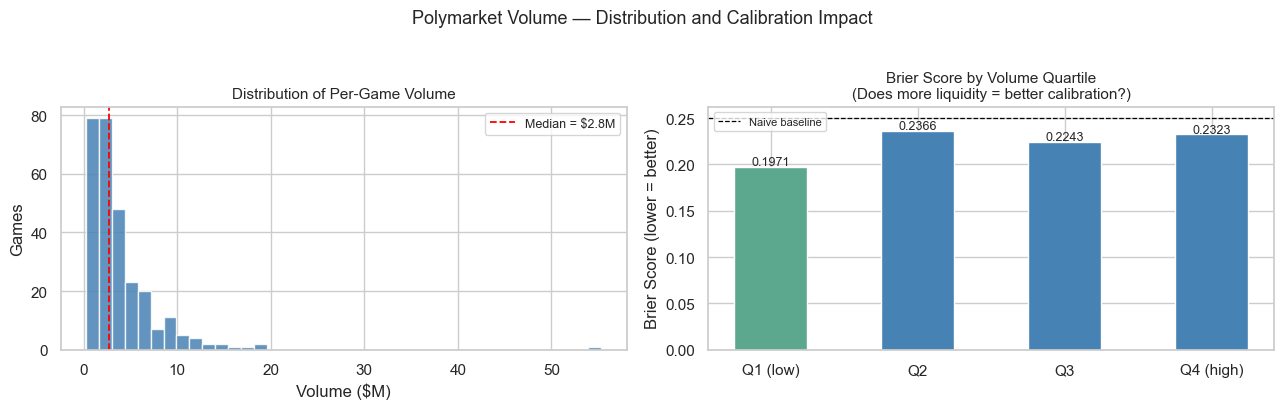

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Volume distribution
axes[0].hist(merged['volume_total'] / 1e6, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(merged['volume_total'].median()/1e6, color='red', linestyle='--', linewidth=1.3,
                label=f'Median = ${merged["volume_total"].median()/1e6:.1f}M')
axes[0].set_title('Distribution of Per-Game Volume', fontsize=11)
axes[0].set_xlabel('Volume ($M)')
axes[0].set_ylabel('Games')
axes[0].legend(fontsize=9)

# BS by volume quartile
q_labels  = [r['Volume Quartile'] for r in vol_cal]
bs_values = [r['Brier Score'] for r in vol_cal]
colors_v  = ['#5ba88f' if bs == min(bs_values) else 'steelblue' for bs in bs_values]
bars = axes[1].bar(q_labels, bs_values, color=colors_v, edgecolor='white', width=0.5)
axes[1].axhline(NAIVE_BS, color='black', linestyle='--', linewidth=0.9, label='Naive baseline')
axes[1].set_title('Brier Score by Volume Quartile\n(Does more liquidity = better calibration?)', fontsize=11)
axes[1].set_ylabel('Brier Score (lower = better)')
axes[1].legend(fontsize=8)
for bar, val in zip(bars, bs_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.002,
                 f'{val:.4f}', ha='center', fontsize=9)

plt.suptitle('Polymarket Volume — Distribution and Calibration Impact', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Super Bowl Deep Dive

**What:** Use the full 6H history data to plot the 14-day Polymarket probability trajectory for the Super Bowl (Seattle Seahawks vs. New England Patriots, Feb 8 2026). Compare it to the sportsbook consensus and ESPN.

**Why the Super Bowl:** It is the highest-volume game in the dataset at $55.29M — 14× the season median. The market was open for 13 days before kickoff, providing the most detailed look at how probability consensus formed for any game in the season.

**Figure meaning:**
- Main chart: Polymarket away (Seahawks) probability over 14 days. A flat line signals market confidence — the crowd's view didn't change much. Any dips or spikes would signal information events (injury reports, weather, sharp activity).
- Annotation: Final probabilities from all four models side-by-side on game day.

In [11]:
# Super Bowl data
sb_row = merged[merged['week'] == 'SB'].iloc[0]
sb_h6  = h6[(h6['away_team'] == 'Seattle Seahawks') &
            (h6['home_team'] == 'New England Patriots') &
            (h6['side'] == 'away')].copy()

print('=== SUPER BOWL — SEATTLE SEAHAWKS @ NEW ENGLAND PATRIOTS ===')
print(f'Date   : {sb_row["date"]}  |  Winner: {sb_row["winner"]}')
print(f'Volume : ${sb_row["volume_total"]:,.0f}  ({sb_row["volume_total"]/1e6:.1f}x median of ${merged["volume_total"].median()/1e6:.1f}M)')
print()
print('Pre-game probabilities (Seahawks/away win):')
print(f'  Polymarket opening  : {sb_row["polymarket_away_open"]:.3f}')
print(f'  ESPN                : {sb_row["espn_away_prob"]:.3f}')
print(f'  Sportsbook consensus: {sb_row["consensus_away"]:.3f}')
print()
print('6H trajectory stats:')
print(f'  Data points : {len(sb_h6)}')
print(f'  Start       : {sb_h6["datetime"].min()}')
print(f'  End         : {sb_h6["datetime"].max()}')
print(f'  Opening     : {sb_h6["probability"].iloc[0]:.3f}')
print(f'  Final pre   : {sb_h6[sb_h6["datetime"] < pd.Timestamp("2026-02-08")]["probability"].iloc[-1]:.3f}')
print(f'  Min / Max   : {sb_h6["probability"].min():.3f} / {sb_h6["probability"].max():.3f}')

=== SUPER BOWL — SEATTLE SEAHAWKS @ NEW ENGLAND PATRIOTS ===
Date   : 2026-02-08  |  Winner: Seattle Seahawks
Volume : $55,291,755  (55.3x median of $2.8M)

Pre-game probabilities (Seahawks/away win):
  Polymarket opening  : 0.675
  ESPN                : 0.697
  Sportsbook consensus: 0.701

6H trajectory stats:
  Data points : 28
  Start       : 2026-01-26 12:00:39
  End         : 2026-02-09 00:00:40
  Opening     : 0.675
  Final pre   : 0.675
  Min / Max   : 0.675 / 0.690


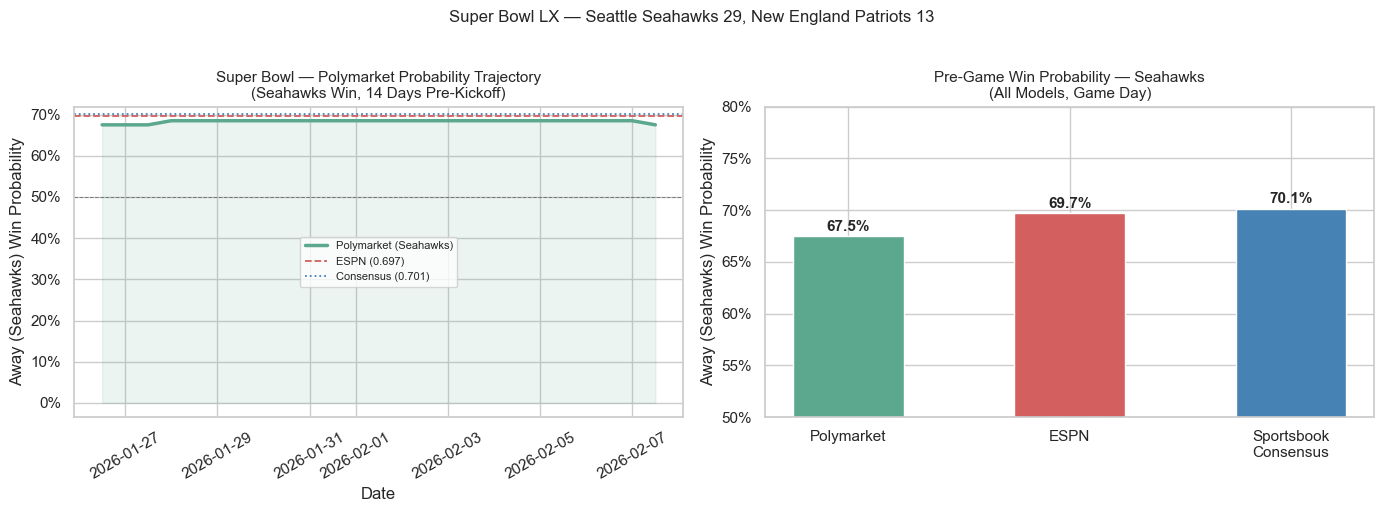

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full trajectory
sb_pre = sb_h6[sb_h6['datetime'] < pd.Timestamp('2026-02-08')]
axes[0].plot(sb_pre['datetime'], sb_pre['probability'],
             color='#5ba88f', linewidth=2.5, label='Polymarket (Seahawks)')
axes[0].fill_between(sb_pre['datetime'], sb_pre['probability'], alpha=0.12, color='#5ba88f')
axes[0].axhline(sb_row['espn_away_prob'], color='#d45f5f', linestyle='--',
                linewidth=1.3, label=f'ESPN ({sb_row["espn_away_prob"]:.3f})')
axes[0].axhline(sb_row['consensus_away'], color='steelblue', linestyle=':',
                linewidth=1.3, label=f'Consensus ({sb_row["consensus_away"]:.3f})')
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=0.7, alpha=0.4)
axes[0].set_title('Super Bowl — Polymarket Probability Trajectory\n(Seahawks Win, 14 Days Pre-Kickoff)', fontsize=11)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Away (Seahawks) Win Probability')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=30)

# 4-model comparison bar
model_names = ['Polymarket', 'ESPN', 'Sportsbook\nConsensus']
model_probs = [sb_row['polymarket_away_open'],
               sb_row['espn_away_prob'],
               sb_row['consensus_away']]
bar_cols = ['#5ba88f','#d45f5f','steelblue']
bars = axes[1].bar(model_names, model_probs, color=bar_cols, edgecolor='white', width=0.5)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=0.9, alpha=0.5)
axes[1].set_title(f'Pre-Game Win Probability — Seahawks\n(All Models, Game Day)', fontsize=11)
axes[1].set_ylabel('Away (Seahawks) Win Probability')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1].set_ylim(0.5, 0.8)
for bar, val in zip(bars, model_probs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Super Bowl LX — Seattle Seahawks 29, New England Patriots 13', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 6b. Consensus Trajectory Deep Dives

**What:** Four games selected to illustrate the four distinct shapes a Polymarket probability trajectory can take. Each shape tells a different story about what the crowd knew, when they knew it, and whether they were right.

| Type | Game | What drove it | Outcome |
|------|------|---------------|---------|
| **Flip** | HOU @ KC, Week 14 | Opened 63% Houston. KC had a historically bad injury-riddled season (6-7 record, 3 starting OL out, Mahomes under pressure from 3-backup O-line). Market gradually repriced KC as the Kansas City home-field narrative took over. Houston won anyway — market was wrong to flip. [ESPN recap](https://www.espn.com/nfl/recap/_/gameId/401772932) |
| **Surge** | DEN @ KC, Week 17 (Christmas) | Opened near 50/50. Then **Patrick Mahomes tore his ACL (Week 15) and backup Gardner Minshew also tore his ACL (Week 16)** in back-to-back weeks. KC was forced to start third-stringer Chris Oladokun — his first career NFL start. Market surged Denver to 88.5% once the full QB situation became clear. Denver won 20-13. [CBS Sports](https://www.cbssports.com/nfl/gametracker/preview/NFL_20251225_DEN@KC/) |
| **Reversal** | ATL @ NO, Week 12 | Opened 50/50. On **November 17, Michael Penix Jr. tore his ACL** against Carolina (Week 11) — the market immediately dropped Atlanta to 24% as Kirk Cousins (0-1 as starter in 2025, 37 years old) took over. Then on **November 19, the Falcons confirmed it was season-ending surgery and announced Cousins would start vs. the Saints**. The market snapped back to 62% for Atlanta — apparently reassessing that even with Cousins, they faced a 2-8 Saints team. Atlanta won. [ESPN report](https://www.espn.com/nfl/story/_/id/47023643/falcons-qb-penix-season-ending-surgery-torn-acl) |
| **Flat** | SEA @ NE, Super Bowl | Opened 67.5%. The market had two full weeks and $55.3M in volume to update its view — and barely moved (67.5%–68.5% range over 13 days). No significant injuries, no weather events, no sharp movement. All three models (Polymarket, ESPN, sportsbook consensus) agreed Seattle were ~68–70% favourites and the crowd never wavered. Seattle won 29-13. |

**Figure meaning:** Each subplot shows the away team's win probability across all pre-kickoff 12H snapshots. The dashed red line marks 50%. Open and close probabilities, total range, and game volume are annotated in each title.

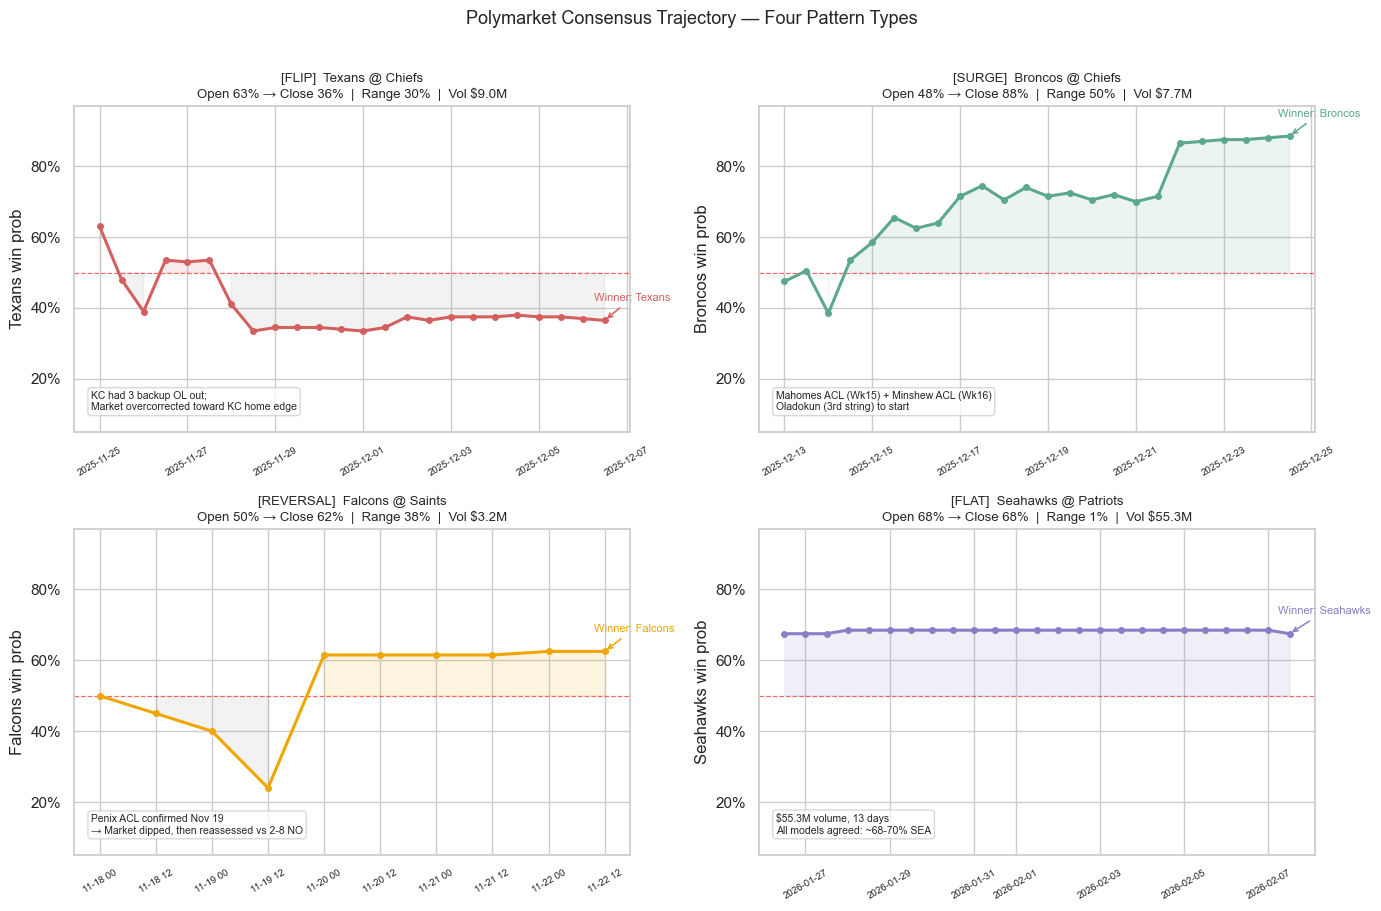

=== DEEP DIVE SUMMARY ===
FLIP       | Houston Texans         @ Kansas City Chiefs     | Open 63.0% -> Close 36.5% | Range 29.5% | Winner: Houston Texans
SURGE      | Denver Broncos         @ Kansas City Chiefs     | Open 47.5% -> Close 88.5% | Range 50.0% | Winner: Denver Broncos
REVERSAL   | Atlanta Falcons        @ New Orleans Saints     | Open 50.0% -> Close 62.5% | Range 38.5% | Winner: Atlanta Falcons
FLAT       | Seattle Seahawks       @ New England Patriots   | Open 67.5% -> Close 67.5% | Range 1.0% | Winner: Seattle Seahawks


In [13]:
# ── Game definitions ─────────────────────────────────────────────────────────
deep_dive_games = [
    dict(away='Houston Texans',   home='Kansas City Chiefs',   label='FLIP',     color='#d45f5f'),
    dict(away='Denver Broncos',   home='Kansas City Chiefs',   label='SURGE',    color='#5ba88f'),
    dict(away='Atlanta Falcons',  home='New Orleans Saints',   label='REVERSAL', color='#f0a500'),
    dict(away='Seattle Seahawks', home='New England Patriots', label='FLAT',     color='#8a7fc7'),
]

# ── Context annotations per game ─────────────────────────────────────────────
game_context = {
    'FLIP':     'KC had 3 backup OL out;\nMarket overcorrected toward KC home edge',
    'SURGE':    'Mahomes ACL (Wk15) + Minshew ACL (Wk16)\nOladokun (3rd string) to start',
    'REVERSAL': 'Penix ACL confirmed Nov 19\n→ Market dipped, then reassessed vs 2-8 NO',
    'FLAT':     '$55.3M volume, 13 days\nAll models agreed: ~68-70% SEA',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, g in zip(axes, deep_dive_games):
    sub = h6[
        (h6['away_team'] == g['away']) &
        (h6['home_team'] == g['home']) &
        (h6['side'] == 'away')
    ].copy()
    sub['game_date'] = pd.to_datetime(sub['date'])
    sub_pre = sub[sub['datetime'] < sub['game_date']].sort_values('datetime')

    row     = merged[(merged['away_team'] == g['away']) & (merged['home_team'] == g['home'])].iloc[0]
    winner  = row['winner']
    volume  = row['volume_total']
    open_p  = sub_pre['probability'].iloc[0]
    close_p = sub_pre['probability'].iloc[-1]
    rng     = sub_pre['probability'].max() - sub_pre['probability'].min()

    ax.plot(sub_pre['datetime'], sub_pre['probability'],
            color=g['color'], linewidth=2.2, marker='o', markersize=4, zorder=3)
    ax.fill_between(sub_pre['datetime'], sub_pre['probability'], 0.5,
                    where=(sub_pre['probability'] >= 0.5),
                    alpha=0.12, color=g['color'], zorder=2)
    ax.fill_between(sub_pre['datetime'], sub_pre['probability'], 0.5,
                    where=(sub_pre['probability'] < 0.5),
                    alpha=0.10, color='#888888', zorder=2)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=0.9, alpha=0.6)

    # Winner annotation
    winner_short = winner.split()[-1]
    ax.annotate(
        'Winner: ' + winner_short,
        xy=(sub_pre['datetime'].iloc[-1], close_p),
        xytext=(-8, 14), textcoords='offset points',
        fontsize=8, color=g['color'],
        arrowprops=dict(arrowstyle='->', color=g['color'], lw=1.1)
    )

    # Context annotation box
    ax.text(0.03, 0.06, game_context[g['label']],
            transform=ax.transAxes, fontsize=7.5,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75, edgecolor='#cccccc'))

    away_short = g['away'].split()[-1]
    home_short = g['home'].split()[-1]
    ax.set_title(
        '[' + g['label'] + ']  ' + away_short + ' @ ' + home_short + '\n' +
        'Open ' + '{:.0%}'.format(open_p) +
        ' → Close ' + '{:.0%}'.format(close_p) +
        '  |  Range ' + '{:.0%}'.format(rng) +
        '  |  Vol $' + '{:.1f}M'.format(volume / 1e6),
        fontsize=9.5
    )
    ax.set_ylabel(away_short + ' win prob')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.set_ylim(0.05, 0.97)

plt.suptitle('Polymarket Consensus Trajectory — Four Pattern Types', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Print summary ─────────────────────────────────────────────────────────────
print('=== DEEP DIVE SUMMARY ===')
for g in deep_dive_games:
    sub = h6[
        (h6['away_team'] == g['away']) &
        (h6['home_team'] == g['home']) &
        (h6['side'] == 'away')
    ].copy()
    sub['game_date'] = pd.to_datetime(sub['date'])
    sub_pre = sub[sub['datetime'] < sub['game_date']].sort_values('datetime')
    row = merged[(merged['away_team'] == g['away']) & (merged['home_team'] == g['home'])].iloc[0]
    o = sub_pre['probability'].iloc[0]
    c = sub_pre['probability'].iloc[-1]
    r = sub_pre['probability'].max() - sub_pre['probability'].min()
    print(
        g['label'].ljust(10) + ' | ' +
        g['away'].ljust(22) + ' @ ' +
        g['home'].ljust(22) + ' | ' +
        'Open ' + '{:.1%}'.format(o) + ' -> ' +
        'Close ' + '{:.1%}'.format(c) + ' | ' +
        'Range ' + '{:.1%}'.format(r) + ' | ' +
        'Winner: ' + str(row['winner'])
    )

## 7. Export

In [14]:
os.makedirs('../outputs', exist_ok=True)

# Brier score comparison
brier_df.to_csv('../outputs/4_brier_4model.csv', index=False)

# Per-game PM data with divergence and movement
export_cols = [
    'week','away_team','home_team','winner','away_win',
    'polymarket_away_open','espn_away_prob','consensus_away',
    'pm_espn_diff','pm_final_pre','pm_movement',
    'volume_total','volume_moneyline','volume_spread','volume_totals',
]
merged[export_cols].to_csv('../outputs/4_polymarket_game_data.csv', index=False)

# Volume calibration table
pd.DataFrame(vol_cal).to_csv('../outputs/4_volume_calibration.csv', index=False)

print('Exported:')
print(f'  4_brier_4model.csv          — {len(brier_df)} models')
print(f'  4_polymarket_game_data.csv  — {len(merged)} games')
print(f'  4_volume_calibration.csv    — {len(vol_cal)} quartiles')

Exported:
  4_brier_4model.csv          — 4 models
  4_polymarket_game_data.csv  — 285 games
  4_volume_calibration.csv    — 4 quartiles
